# Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load Dataset

In [41]:
df = pd.read_csv('mall_customers.csv')

print(df.head())

   CustomerID  Annual Income (k$)  Spending Score (1-100)
0           1                  55                      41
1           2                 109                      29
2           3                  75                      54
3           4                  41                       6
4           5                  70                      33


#Check & Clean Column Names

In [42]:
print("Columns before cleaning:", df.columns)

# Remove extra spaces if any
df.columns = df.columns.str.strip()

print("Columns after cleaning:", df.columns)

Columns before cleaning: Index(['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')
Columns after cleaning: Index(['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')


#Understand the Data

In [43]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              50 non-null     int64
 1   Annual Income (k$)      50 non-null     int64
 2   Spending Score (1-100)  50 non-null     int64
dtypes: int64(3)
memory usage: 1.3 KB
None
       CustomerID  Annual Income (k$)  Spending Score (1-100)
count    50.00000           50.000000                50.00000
mean     25.50000           76.060000                48.66000
std      14.57738           26.720328                32.22916
min       1.00000           20.000000                 1.00000
25%      13.25000           57.500000                18.25000
50%      25.50000           76.500000                49.00000
75%      37.75000           97.000000                79.25000
max      50.00000          117.000000                99.00000


#Data Cleaning

In [44]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

CustomerID                0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


#Exploratory Data Analysis (EDA)

#Income Distribution

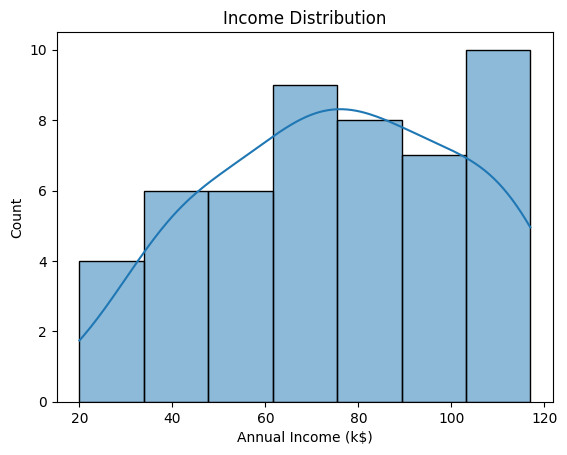

In [45]:
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title("Income Distribution")
plt.show()

#Spending Score Distribution

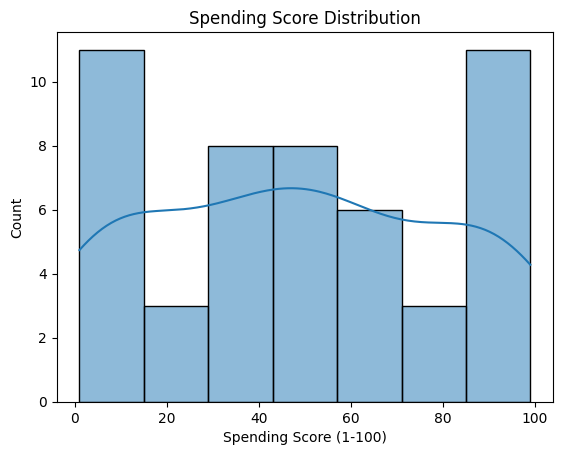

In [46]:
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title("Spending Score Distribution")
plt.show()

#Income vs Spending

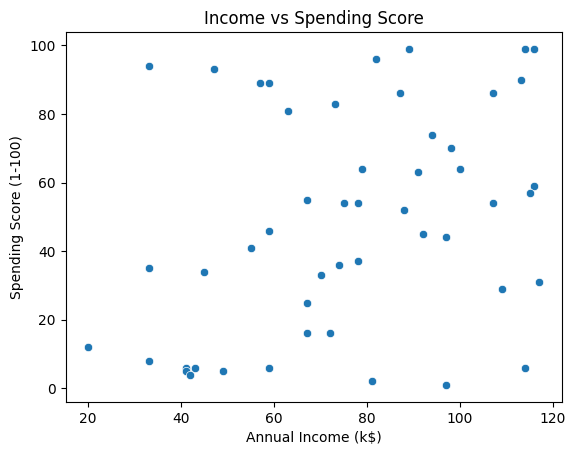

In [47]:
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

#Correlation Heatmap

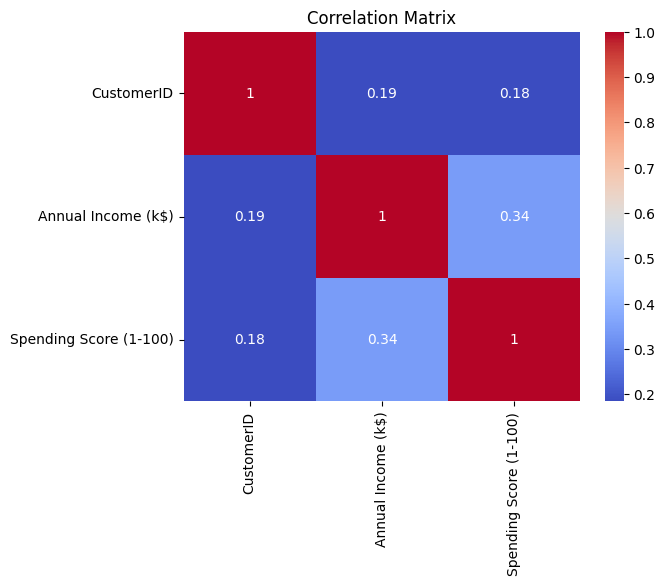

In [48]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#Feature Selection

In [49]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

#Feature Scaling

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Elbow Method

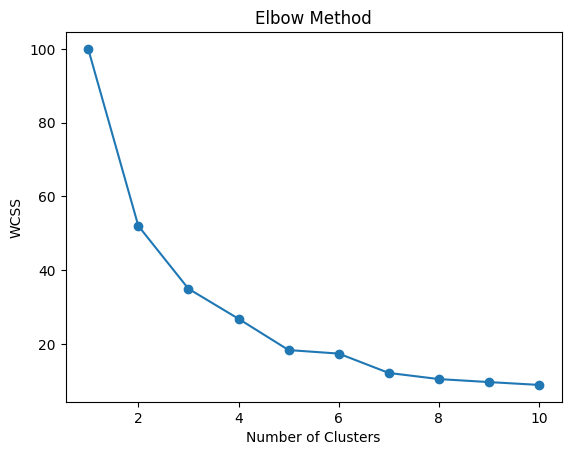

In [51]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

#Apply KMeans

In [52]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

#Create Customer Personas

In [53]:
def label_customer(row):
    if row['Cluster'] == 0:
        return "High Income - High Spending"
    elif row['Cluster'] == 1:
        return "Low Income - High Spending"
    elif row['Cluster'] == 2:
        return "High Income - Low Spending"
    elif row['Cluster'] == 3:
        return "Low Income - Low Spending"
    else:
        return "Average Customers"

df['Customer Type'] = df.apply(label_customer, axis=1)

#Interactive Visualization

In [54]:
fig = px.scatter(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    color='Customer Type',
    title="Customer Segmentation"
)

fig.show()

#Cluster Analysis

In [55]:
summary = df.groupby('Customer Type').mean(numeric_only=True)
print(summary)

                             CustomerID  Annual Income (k$)  \
Customer Type                                                 
Average Customers             19.142857           72.142857   
High Income - High Spending   26.111111          107.111111   
High Income - Low Spending    29.666667           55.333333   
Low Income - High Spending    23.100000           40.600000   
Low Income - Low Spending     33.000000           99.181818   

                             Spending Score (1-100)  Cluster  
Customer Type                                                 
Average Customers                         37.928571      4.0  
High Income - High Spending               36.222222      0.0  
High Income - Low Spending                88.166667      2.0  
Low Income - High Spending                12.100000      1.0  
Low Income - Low Spending                 84.181818      3.0  


#Business Insights

In [56]:
print("\n📊 BUSINESS INSIGHTS:")

for customer_type in df['Customer Type'].unique():
    print(f"\n{customer_type}:")
    subset = df[df['Customer Type'] == customer_type]
    print("Count:", len(subset))
    print("Avg Income:", subset['Annual Income (k$)'].mean())
    print("Avg Spending:", subset['Spending Score (1-100)'].mean())


📊 BUSINESS INSIGHTS:

Average Customers:
Count: 14
Avg Income: 72.14285714285714
Avg Spending: 37.92857142857143

High Income - High Spending:
Count: 9
Avg Income: 107.11111111111111
Avg Spending: 36.22222222222222

Low Income - High Spending:
Count: 10
Avg Income: 40.6
Avg Spending: 12.1

High Income - Low Spending:
Count: 6
Avg Income: 55.333333333333336
Avg Spending: 88.16666666666667

Low Income - Low Spending:
Count: 11
Avg Income: 99.18181818181819
Avg Spending: 84.18181818181819


#Save Final Output

In [57]:
df.to_csv('segmented_customers.csv', index=False)

print("✅ Project Completed Successfully!")

✅ Project Completed Successfully!
